In [1]:
# !pip install git+https://github.com/speechbrain/speechbrain.git@develop -q
# !pip install -q -U git+https://github.com/wenet-e2e/wespeaker.git -q
!pip install speechbrain
!pip install -q protobuf==3.20.2
!pip install -q pyroomacoustics
!pip install -q s3prl
!pip install -q whisper
!pip install -q onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 28.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 38.6 MB/s eta 0:00:00
  Attempting uninstall: ruamel.yaml
    Found existing installation: ruamel.yaml 0.19.1
    Uninstalling ruamel.yaml-0.19.1:
      Successfully uninstalled ruamel.yaml-0.19.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.2 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 3.20.2 which is incompatible.
ray 2.54.0 requires protobuf>=3.20

In [7]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.compliance.kaldi as kaldi
from torch.utils.data import Dataset, DataLoader
from speechbrain.inference.speaker import EncoderClassifier
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
try:
    import umap
except ImportError:
    print("Lưu ý: Thư viện 'umap-learn' chưa cài, sẽ bỏ qua visualize UMAP.")

# ==========================================
# 1. CÁC HÀM TIỆN ÍCH (KEEP)
# ==========================================
def compute_fbank(waveform, sample_rate=16000, num_mel_bins=80, frame_length=25, frame_shift=10):
    feat = kaldi.fbank(waveform, num_mel_bins=num_mel_bins, frame_length=frame_length, frame_shift=frame_shift, sample_frequency=sample_rate, window_type='hamming')
    feat = feat - torch.mean(feat, 0)
    return feat

class WrappedBackbone(nn.Module):
    def __init__(self, local_model_dir="/kaggle/input/datasets/richardjacob04/ecapa-tdnn-local"):
        super().__init__()
        
        # Tạo một thư mục tạm có quyền ghi trên Kaggle để SpeechBrain lưu cache/symlink
        writable_savedir = "/kaggle/working/speechbrain_cache"
        os.makedirs(writable_savedir, exist_ok=True)
        
        classifier = EncoderClassifier.from_hparams(
            source=local_model_dir, 
            savedir=writable_savedir,  # Sửa savedir thành thư mục có quyền ghi
            run_opts={"device":"cuda" if torch.cuda.is_available() else "cpu"}
        )
        self.model = classifier.mods.embedding_model

    def forward(self, feats):
        wav_lens = torch.ones(feats.shape[0], device=feats.device)
        return self.model(feats, wav_lens).squeeze(1)

import librosa
CHUNK_LEN   = 3 * 16000   # 3 giây
STEP_LEN    = CHUNK_LEN // 2  # overlap 50% = 1.5 giây
def preprocess_to_chunks(waveform_tensor, chunk_len=CHUNK_LEN, step_len=STEP_LEN):
    """Chia waveform thành nhiều chunk 3s với overlap 50%."""
    current_len = waveform_tensor.size(1)
    chunks = []
    if current_len < chunk_len:
        # Quá ngắn → pad
        pad_amt = chunk_len - current_len
        chunks.append(F.pad(waveform_tensor, (0, pad_amt), "constant", 0))
    else:
        # Sliding window
        for start in range(0, current_len - chunk_len + 1, step_len):
            chunks.append(waveform_tensor[:, start:start + chunk_len])
        # Chunk cuối (nếu còn sót)
        if (current_len - chunk_len) % step_len != 0:
            chunks.append(waveform_tensor[:, -chunk_len:])
    return chunks  # list of [1, chunk_len]
class MultiChunkTrialDataset(Dataset):
    """Dataset trích xuất embedding bằng multi-chunk averaging."""
    def __init__(self, wav_list, root_dir):
        self.wav_list = wav_list
        self.root_dir = root_dir
    def __len__(self):
        return len(self.wav_list)
    def __getitem__(self, idx):
        rel_path = self.wav_list[idx]
        full_path = os.path.join(self.root_dir, rel_path)
        try:
            waveform, sr = torchaudio.load(full_path)
            if sr != 16000:
                waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)
            if waveform.shape[0] > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            waveform = waveform * (1 << 15)
            chunks    = preprocess_to_chunks(waveform)
            fbanks    = [compute_fbank(c) for c in chunks]
            # Stack thành [N_chunks, T, 80]
            fbank_tensor = torch.stack(fbanks)
        except Exception as e:
            print(f"[WARN] {rel_path}: {e}")
            # Trả về 1 chunk zero
            fbank_tensor = torch.zeros((1, 300, 80))
        return fbank_tensor, rel_path   # [N, T, 80], str
def extract_embeddings_multichunk(backbone, wav_list, root_dir, device, batch_size=32):
    """
    Trích xuất embedding bằng cách:
    1. Chia từng file thành N chunks 3s (sliding window 50%)
    2. Extract embedding từng chunk
    3. Average → embedding cuối
    """
    emb_cache = {}
    dataset   = MultiChunkTrialDataset(wav_list, root_dir)
    print(f"[*] Đang trích xuất {len(dataset)} embeddings (multi-chunk)...")
    with torch.no_grad():
        for fbank_tensor, rel_path in tqdm(dataset):
            # fbank_tensor: [N_chunks, T, 80]
            n_chunks = fbank_tensor.size(0)
            chunk_embeds = []
            for i in range(0, n_chunks, batch_size):
                batch = fbank_tensor[i:i+batch_size].to(device)  # [B, T, 80]
                wav_lens = torch.ones(batch.size(0), device=device)
                out = backbone(batch)
                chunk_embeds.append(out.cpu())
            all_embeds = torch.cat(chunk_embeds, dim=0)           # [N, D]
            final_emb  = F.normalize(all_embeds.mean(dim=0, keepdim=True), p=2, dim=1)
            emb_cache[rel_path] = final_emb.squeeze(0)            # [D]
    return emb_cache


Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


[*] Đang trích xuất 17774 embeddings (multi-chunk)...


100%|██████████| 17774/17774 [09:03<00:00, 32.71it/s]



 ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH (EVALUATION METRICS)  
  AUC (Area Under Curve)      : 0.9961
  EER (Equal Error Rate)      : 1.9775 %
  Threshold tại EER           : 0.3129
  FPR tại EER                 : 1.9775 %
  FNR tại EER                 : 1.9179 %
--------------------------------------------------
  minDCF (P_tgt=0.01)         : 0.0043
  Threshold tại minDCF        : 0.5542



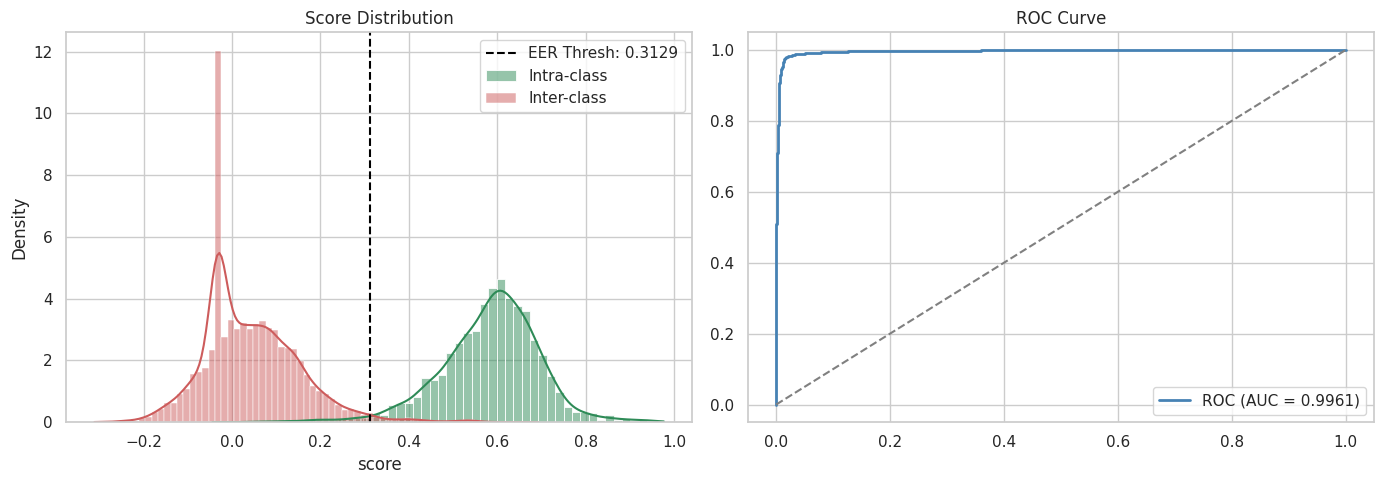

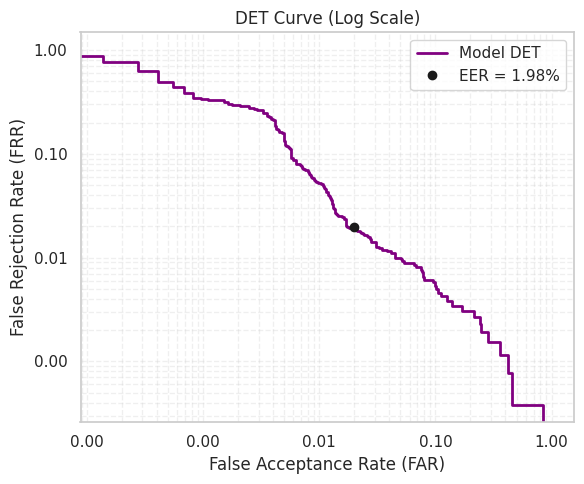

[*] Đang gom cụm tự động (K-Means) và chuẩn bị t-SNE...


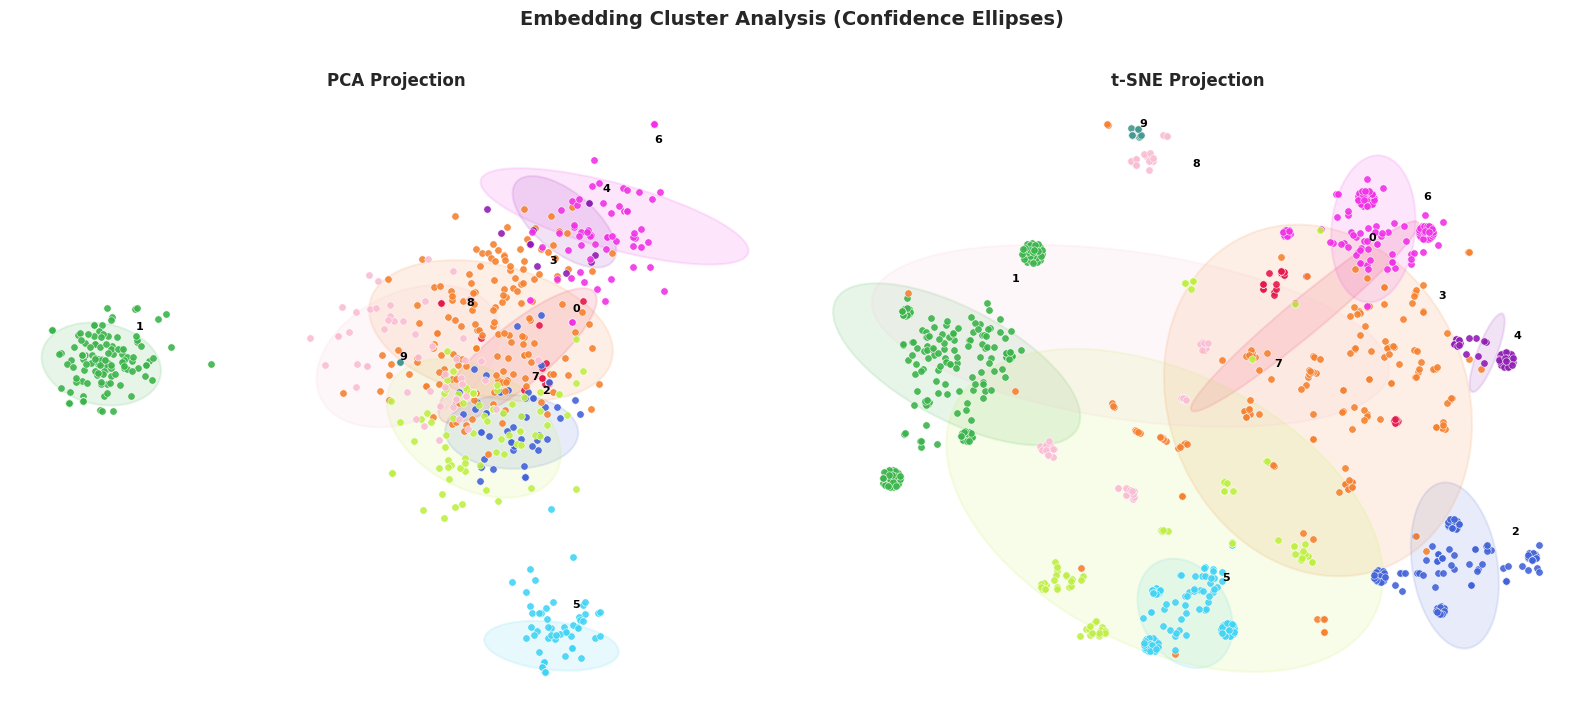

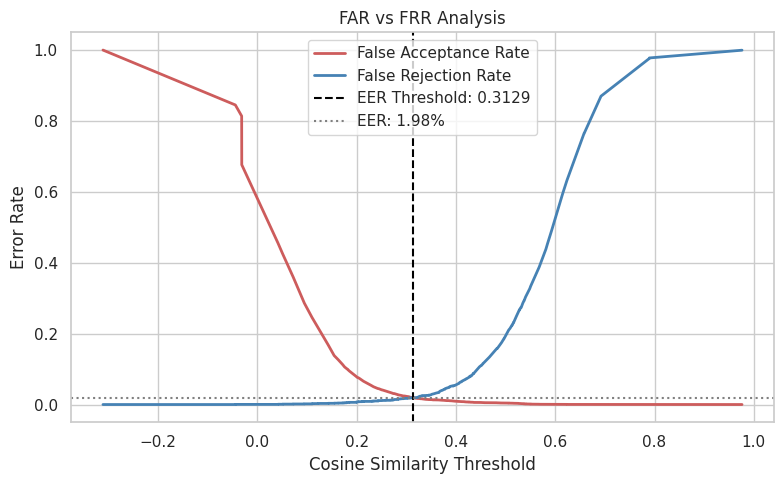

[*] Đang phân tích độ phân tách cụm (Cluster Separability)...


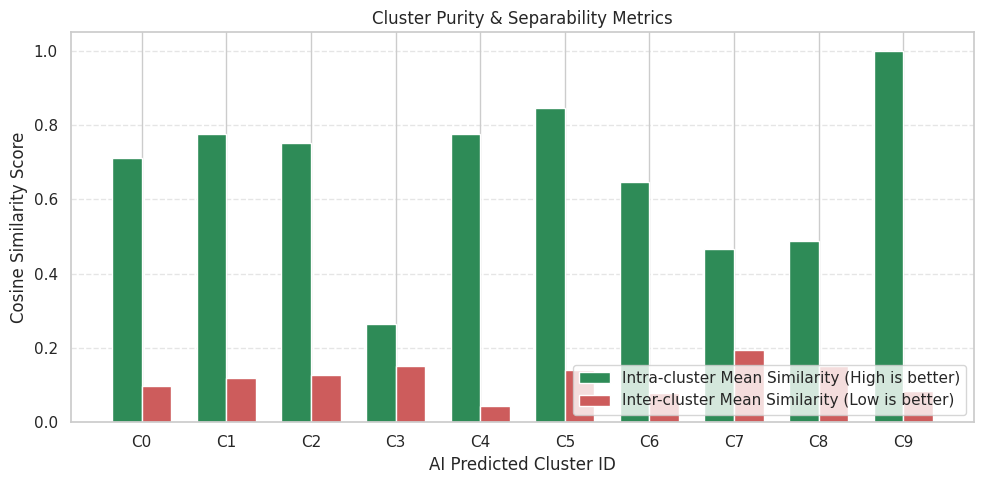

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
# Thay bằng module backbone của bạn nếu cần
# from your_module import WrappedBackbone, TrialWavDataset 

# ==========================================
# 2. HÀM EVALUATE CHÍNH
# ==========================================
def evaluate():
    # --- Cấu hình ---
    EVAL_ROOT = "/kaggle/input/datasets/minhtu4n/vox-o-vietnamese/VoxVietnameseFullTestSet"
    TRIALS_FILE = os.path.join(EVAL_ROOT, "test_list_gt_1.csv")
    CHECKPOINT_PATH = "/kaggle/input/datasets/richardjacob04/ecapa-tdnn-aam-loss/best_model.ckpt"
    LOCAL_MODEL_DIR = "/kaggle/input/datasets/richardjacob04/ecapa-tdnn-local"
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Load Model
    backbone = WrappedBackbone(local_model_dir=LOCAL_MODEL_DIR)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    new_state_dict = {k.replace('backbone.model.', ''): v for k, v in checkpoint['state_dict'].items() if k.startswith('backbone.model.')}
    backbone.model.load_state_dict(new_state_dict)
    backbone.to(DEVICE).eval()

    # 2. Parse Trials
    trials, unique_wavs = [], set()
    with open(TRIALS_FILE, 'r', encoding='utf-8-sig') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                label, p1, p2 = int(parts[0]), parts[1], parts[2]
                trials.append((label, p1, p2))
                unique_wavs.update([p1, p2])
    unique_wavs = sorted(list(unique_wavs))

    # 3. Trích xuất Embedding (Lưu vào emb_cache để visualize t-SNE)
    emb_cache = extract_embeddings_multichunk(
        backbone   = backbone,
        wav_list   = unique_wavs,
        root_dir   = EVAL_ROOT,
        device     = DEVICE,
        batch_size = 32
    )

    # 4. Tính Scores
    y_true, y_scores = [], []
    for label, p1, p2 in trials:
        if p1 in emb_cache and p2 in emb_cache:
            score = torch.dot(emb_cache[p1], emb_cache[p2]).item()
            y_true.append(label); y_scores.append(score)

    # ==========================================
    # 3. BỔ SUNG VISUALIZE
    # ==========================================
    if len(y_scores) > 0:
        # ==========================================
        # --- A. Tính EER, AUC & minDCF ---
        # ==========================================
        fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1)
        fnr = 1 - tpr
        
        # 1. Tính EER và các chỉ số tại EER
        idx_eer = np.nanargmin(np.abs(fnr - fpr))
        eer = fpr[idx_eer] * 100
        thresh_eer = thresholds[idx_eer]
        fpr_at_eer = fpr[idx_eer] * 100
        fnr_at_eer = fnr[idx_eer] * 100
        roc_auc = auc(fpr, tpr)

        # 2. Tính minDCF (Theo chuẩn cấu hình NIST SRE thông dụng)
        P_target = 0.01  # Bạn có thể đổi thành 0.05 tùy theo dataset/bài báo
        C_miss = 1.0
        C_fa = 1.0
        
        # Tính mảng DCF cho tất cả các ngưỡng
        dcf_scores = C_miss * P_target * fnr + C_fa * (1 - P_target) * fpr
        
        # Tìm giá trị DCF nhỏ nhất và Threshold tương ứng
        min_dcf_idx = np.argmin(dcf_scores)
        min_dcf = dcf_scores[min_dcf_idx]
        min_dcf_thresh = thresholds[min_dcf_idx]

        # In kết quả theo format bảng báo cáo khoa học
        print(f"\n{'='*50}")
        print(f"{'ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH (EVALUATION METRICS)':^50}")
        print(f"{'='*50}")
        print(f"  AUC (Area Under Curve)      : {roc_auc:.4f}")
        print(f"  EER (Equal Error Rate)      : {eer:.4f} %")
        print(f"  Threshold tại EER           : {thresh_eer:.4f}")
        print(f"  FPR tại EER                 : {fpr_at_eer:.4f} %")
        print(f"  FNR tại EER                 : {fnr_at_eer:.4f} %")
        print(f"{'-'*50}")
        print(f"  minDCF (P_tgt={P_target})         : {min_dcf:.4f}")
        print(f"  Threshold tại minDCF        : {min_dcf_thresh:.4f}")
        print(f"{'='*50}\n")
        

        # === TẠO LẠI BIẾN df ĐỂ TRÁNH LỖI NAME_ERROR ===
        df = pd.DataFrame({"score": y_scores, "label": y_true})
        
        # --- B. Biểu đồ Distribution & ROC ---
        sns.set_theme(style="whitegrid")
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 2, 1)
        sns.histplot(df[df['label']==1]['score'], color='seagreen', label='Intra-class', kde=True, stat='density', alpha=0.5)
        sns.histplot(df[df['label']==0]['score'], color='indianred', label='Inter-class', kde=True, stat='density', alpha=0.5)
        # Đã đồng bộ tên biến thành thresh_eer
        plt.axvline(thresh_eer, color='black', linestyle='--', label=f'EER Thresh: {thresh_eer:.4f}')
        plt.title('Score Distribution'); plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(fpr, tpr, color='steelblue', label=f'ROC (AUC = {roc_auc:.4f})', linewidth=2)
        plt.plot([0, 1], [0, 1], '--', color='gray')
        plt.title('ROC Curve'); plt.legend(loc="lower right")
        plt.tight_layout(); plt.show()

        # --- C. DET Curve (Detection Error Tradeoff) ---
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, fnr, color='purple', linewidth=2, label='Model DET')
        plt.xscale('log')
        plt.yscale('log')
        from matplotlib.ticker import ScalarFormatter
        for axis in [plt.gca().xaxis, plt.gca().yaxis]:
            axis.set_major_formatter(ScalarFormatter())
        plt.xlabel('False Acceptance Rate (FAR)')
        plt.ylabel('False Rejection Rate (FRR)')
        plt.title('DET Curve (Log Scale)')
        plt.plot(eer/100, eer/100, 'ko', label=f'EER = {eer:.2f}%')
        plt.legend()
        plt.grid(True, which="both", ls="--", alpha=0.3)
        plt.tight_layout()
        plt.show()

    # ==========================================
    # --- D. Phân cụm tự động & PCA/t-SNE (IMPROVED) ---
    # ==========================================
    print("[*] Đang gom cụm tự động (K-Means) và chuẩn bị t-SNE...")
    
    import matplotlib.patches as mpatches
    from matplotlib.patches import Ellipse
    import matplotlib.transforms as transforms
    
    # ── Helper: vẽ confidence ellipse từ covariance matrix ─────────────────────
    def draw_confidence_ellipse(ax, coords, color, n_std=1.8, alpha_fill=0.12, lw=1.5):
        """Vẽ ellipse bao quanh cụm dựa trên PCA của scatter matrix."""
        if len(coords) < 3:
            return None
        cov = np.cov(coords[:, 0], coords[:, 1])
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        # Đảm bảo eigenvalues dương
        eigenvalues = np.clip(eigenvalues, 0, None)
        # Góc xoay của ellipse
        angle = np.degrees(np.arctan2(*eigenvectors[:, 1][::-1]))
        # Bán trục
        width, height = 2 * n_std * np.sqrt(eigenvalues)
        center_x, center_y = coords.mean(axis=0)
        ellipse = Ellipse(
            xy=(center_x, center_y),
            width=width, height=height,
            angle=angle,
            facecolor=color, alpha=alpha_fill,
            edgecolor=color, linewidth=lw,
            zorder=1
        )
        ax.add_patch(ellipse)
        return ellipse
    
    # ── Tạo palette màu sắc phân biệt rõ ràng ──────────────────────────────────
    def get_distinct_colors(n):
        """Tạo n màu phân biệt nhau rõ ràng."""
        base_colors = [
            '#E6194B', '#3CB44B', '#4363D8', '#F58231', '#911EB4',
            '#42D4F4', '#F032E6', '#BFEF45', '#FABED4', '#469990',
            '#DCBEFF', '#9A6324', '#FFFAC8', '#800000', '#AAFFC3',
            '#808000', '#FFD8B1', '#000075', '#A9A9A9', '#FFFFFF',
        ]
        colors = []
        for i in range(n):
            colors.append(base_colors[i % len(base_colors)])
        return colors
    
    # ── Main visualize function ──────────────────────────────────────────────────
    def plot_clusters_with_ellipse(ax, coords, labels, title):
        unique_labels = np.unique(labels)
        n_clusters = len(unique_labels)
        colors = get_distinct_colors(n_clusters)
        color_map = {lbl: colors[i] for i, lbl in enumerate(unique_labels)}
        
        ax.set_facecolor('white')
        ax.grid(False)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    
        for lbl in unique_labels:
            mask = labels == lbl
            cluster_coords = coords[mask]
            c = color_map[lbl]
            
            # 1. Vẽ dots
            ax.scatter(
                cluster_coords[:, 0], cluster_coords[:, 1],
                color=c, s=28, zorder=3, edgecolors='white', linewidths=0.4, alpha=0.9
            )
            
            # 2. Vẽ confidence ellipse
            draw_confidence_ellipse(ax, cluster_coords, color=c, n_std=1.8)
            
            # 3. Label cluster ở góc trên phải của ellipse
            if len(cluster_coords) > 0:
                cx, cy = cluster_coords.mean(axis=0)
                # Offset label ra ngoài ellipse một chút
                std_x = cluster_coords[:, 0].std() if len(cluster_coords) > 1 else 1
                std_y = cluster_coords[:, 1].std() if len(cluster_coords) > 1 else 1
                offset_x = std_x * 1.2
                offset_y = std_y * 1.2
                ax.text(
                    cx + offset_x, cy + offset_y,
                    str(lbl),
                    fontsize=8, fontweight='bold',
                    color='black', zorder=5,
                    ha='left', va='bottom'
                )
    
        ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    
    # ── Chạy embedding + visualize ───────────────────────────────────────────────
    embeddings_list = [emb.numpy() for emb in emb_cache.values()]
    emb_np = np.array(embeddings_list)
    
    NUM_CLUSTERS = 10
    kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init='auto')
    predicted_labels = kmeans.fit_predict(emb_np)
    
    MAX_VIS = 1000
    if len(emb_np) > MAX_VIS:
        np.random.seed(42)
        idx_vis = np.random.choice(len(emb_np), MAX_VIS, replace=False)
        vis_emb  = emb_np[idx_vis]
        vis_lb   = predicted_labels[idx_vis]
    else:
        vis_emb = emb_np
        vis_lb  = predicted_labels
    
    if len(vis_emb) > 0:
        pca_res  = PCA(n_components=2).fit_transform(vis_emb)
        tsne_res = TSNE(
            n_components=2,
            perplexity=min(30, len(vis_emb) - 1),
            random_state=42
        ).fit_transform(vis_emb)
    
        fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')
        plot_clusters_with_ellipse(axes[0], pca_res,  vis_lb, 'PCA Projection')
        plot_clusters_with_ellipse(axes[1], tsne_res, vis_lb, 't-SNE Projection')
        plt.suptitle('Embedding Cluster Analysis (Confidence Ellipses)', fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()

        # ==========================================
        # --- E. Biểu đồ FAR vs FRR (Error Rates) ---
        # ==========================================
        plt.figure(figsize=(8, 5))
        min_score, max_score = min(y_scores), max(y_scores)
        valid_idx = (thresholds >= min_score) & (thresholds <= max_score)
        
        plt.plot(thresholds[valid_idx], fpr[valid_idx], label='False Acceptance Rate', color='indianred', linewidth=2)
        plt.plot(thresholds[valid_idx], fnr[valid_idx], label='False Rejection Rate', color='steelblue', linewidth=2)
        # Đã đồng bộ tên biến thành thresh_eer
        plt.axvline(thresh_eer, color='black', linestyle='--', label=f'EER Threshold: {thresh_eer:.4f}')
        plt.axhline(eer/100, color='gray', linestyle=':', label=f'EER: {eer:.2f}%')
        
        plt.xlabel('Cosine Similarity Threshold')
        plt.ylabel('Error Rate')
        plt.title('FAR vs FRR Analysis')
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Phần F bên dưới bạn giữ nguyên như cũ...

        # ==========================================
        # --- F. Cluster Separability Analysis (Thay Heatmap) ---
        # ==========================================
        print("[*] Đang phân tích độ phân tách cụm (Cluster Separability)...")
        centroids = []
        intra_sims = []
        
        unique_clusters = np.unique(vis_lb)
        for c in unique_clusters:
            c_embs = vis_emb[vis_lb == c]
            centroid = c_embs.mean(axis=0)
            centroids.append(centroid)
            
            # Đo lường độ tụ trung bình nội bộ cụm (Intra-cluster)
            if len(c_embs) > 1:
                sims = cosine_similarity(c_embs, [centroid])
                intra_sims.append(sims.mean())
            else:
                intra_sims.append(1.0)
                
        centroids = np.array(centroids)
        # Đo lường độ tương đồng giữa các tâm cụm (Inter-cluster)
        inter_matrix = cosine_similarity(centroids)
        np.fill_diagonal(inter_matrix, np.nan) 
        inter_sims = np.nanmean(inter_matrix, axis=1)

        plt.figure(figsize=(10, 5))
        x = np.arange(len(unique_clusters))
        width = 0.35
        
        plt.bar(x - width/2, intra_sims, width, label='Intra-cluster Mean Similarity (High is better)', color='seagreen')
        plt.bar(x + width/2, inter_sims, width, label='Inter-cluster Mean Similarity (Low is better)', color='indianred')
        
        plt.xlabel('AI Predicted Cluster ID')
        plt.ylabel('Cosine Similarity Score')
        plt.title('Cluster Purity & Separability Metrics')
        plt.xticks(x, [f'C{int(c)}' for c in unique_clusters])
        plt.legend(loc='lower right')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    evaluate()